![logo](../../.././docs/images/Logo_Destination_Earth_Colours.png)

## Polytope Climate-DT Monthly Mean Polygon (Projections) example notebook

This notebook shows how to use earthkit-data and earthkit-plots to extract a **monthly mean field over a polygon** from the Climate DT `clmn` stream via Polytope using the **SSP3-7.0 projections** experiment, and plot it using earthkit-plots.

The `clmn` stream provides time-averaged monthly fields (e.g. `avg_2t` for 2 m temperature). Unlike the hourly `clte` stream, requests use `year` and `month` keys instead of `date` and `time`.

Before running the notebook you need to set up your credentials. See the main readme of this repository for different ways to do this or use the following cells to authenticate.

You will need to generate your credentials using the desp-authentication.py script.

This can be run as follows:

In [ ]:
%%capture cap
%run ../../desp-authentication.py

This will generate a token that can then be used by earthkit and polytope.

In [ ]:
output_1 = cap.stdout.split('}\n')
access_token = output_1[-1][0:-1]

# Requirements
To run this notebook install the following:
* pip install earthkit-data
* pip install earthkit-plots
* pip install earthkit-regrid  (Optional for spectral variables)
* pip install cf-units         (Optional for unit conversion in maps)

If you do not have eccodes installed please install eccodes using conda as it is a dependency of earthkit, or install earthkit via conda

* conda install eccodes -c conda-forge
* conda install earthkit-data -c conda-forge

In [ ]:
import earthkit.data
import earthkit.plots
import earthkit.geo.cartography

In [ ]:
# Defaults to making a live data request. Set to False to use the cached file instead.
import os

LIVE_REQUEST = os.getenv("LIVE_REQUEST", "true").lower() == "true"
LIVE_REQUEST

In [ ]:
countries = ["Poland"] # List of countries

shapes = earthkit.geo.cartography.country_polygons(countries, resolution=50e6)

request = {
    "activity":    "projections",
    "class":       "d1",
    "dataset":     "climate-dt",
    "experiment":  "SSP3-7.0",
    "generation":  "2",
    "expver":      "0001",
    "model":       "IFS-NEMO",
    "realization": "1",
    "resolution":  "high",
    "stream":      "clmn",
    "type":        "fc",
    "year":        "2040",
    "month":       "7",
    "levtype":     "sfc",
    "param":       "avg_2t",
    "feature": {
        "type": "polygon",
        "shape": shapes
    },
}

In [ ]:
data_file = "../data/climate-dt-earthkit-fe-polygon-clmn-projections.covjson"
if LIVE_REQUEST:
    data = earthkit.data.from_source(
        "polytope", "destination-earth", request,
        address="polytope.mn5.apps.dte.destination-earth.eu", stream=False
    )
    data.to_target("file", data_file)
else:
    data = earthkit.data.from_source("file", data_file)

In [ ]:
ds = data.to_xarray()
ds

<xarray.Dataset> Size: 308kB
Dimensions:    (datetimes: 1, number: 1, steps: 1, points: 7707)
Coordinates:
  * datetimes  (datetimes) <U20 80B '2040-07-01T00:00:00Z'
  * number     (number) int64 8B 0
  * steps      (steps) int64 8B 0
  * points     (points) int64 62kB 0 1 2 3 4 5 ... 7701 7702 7703 7704 7705 7706
    latitude   (points) float64 62kB 49.07 49.07 49.07 ... 54.82 54.82 54.82
    longitude  (points) float64 62kB 22.63 22.73 22.83 ... 18.11 18.23 18.34
    levelist   (points) float64 62kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Data variables:
    avg_2t     (datetimes, number, steps, points) float64 62kB 294.4 ... 290.8
Attributes: (12/16)
    activity:       projections
    class:          d1
    dataset:        climate-dt
    experiment:     ssp3-7.0
    expver:         0001
    generation:     2
    ...             ...
    stream:         clmn
    type:           fc
    number:         0
    Forecast date:  2040-07-01T00:00:00Z
    step:           0
    date:           2040-07-01T00:00:00Z

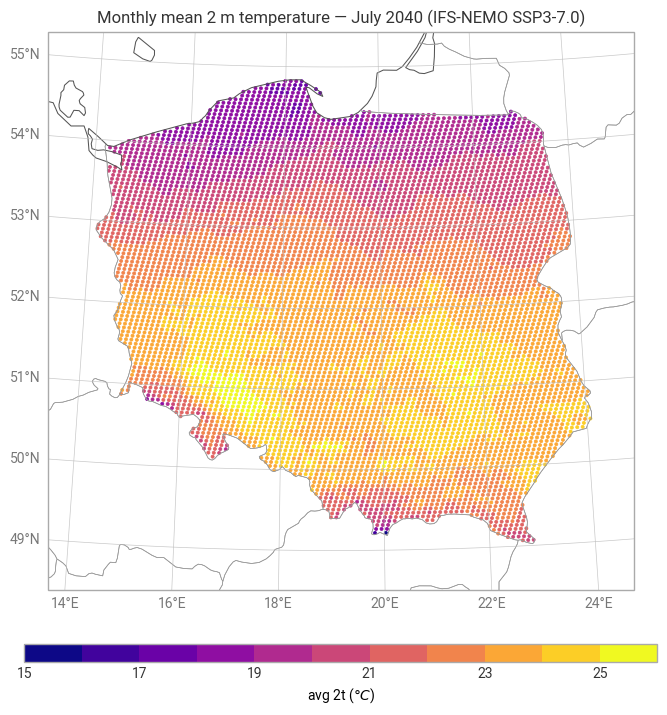

In [ ]:
chart = earthkit.plots.Map(domain="Poland")
chart.point_cloud(
    ds["avg_2t"],
    units="celsius"
)

chart.coastlines()
chart.borders()
chart.gridlines()

chart.title("Monthly mean 2 m temperature — July 2040 (IFS-NEMO SSP3-7.0)")

chart.legend()

chart.show()